# Seção 1 – Modelagem preditiva da venda diária
**Pergunta:** quanto vamos vender (receita aprovada e nº de pedidos) em cada dia, com **7 dias de antecedência**?

Desenho da solução, resumido:
1. Série diária (242 dias) – amostra pequena, então modelos simples e regularizados são o ponto de partida.
2. Baseline ingênuo sazonal (mesmo dia da semana, 7 dias atrás) como régua mínima.
3. Ridge (interpretável) e LightGBM (captura não linearidades e interações) sobre o log do alvo, mais a média dos dois.
4. Validação temporal: *walk-forward* (4 janelas de 14 dias, treino sempre no passado) e *holdout* nos últimos 30 dias (junho/2026), tocado uma única vez.
5. Dois cenários de informação: **sem plano promocional** (só calendário + histórico) e **com plano promocional**
   (acrescenta a taxa de desconto do dia como se fosse conhecida com antecedência; é um limite superior otimista, testado na seção de sensibilidade).

In [1]:
import json, sys, warnings
sys.path.insert(0, '..')
warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from sklearn.inspection import permutation_importance
from src.data import carregar, serie_diaria
from src.features import calendario, com_defasagens, H
from src.modeling import metricas, modelos, prever_modelo, baseline_sazonal, DIAS_HOLDOUT
from src.viz import aplicar_estilo, salvar, milhoes, AZUL, LARANJA, AQUA, CINZA
aplicar_estilo()
d = serie_diaria(carregar())
d['tx_desc'] = d.vlr_venda_desconto / (d.receita_aprovada + d.vlr_venda_desconto)
ALVOS = {'receita_aprovada': 'Receita aprovada', 'nr_pedidos': 'Nº de pedidos'}
N_FOLDS, PASSO = 4, 14
print(f'Horizonte H = {H} dias | holdout = {DIAS_HOLDOUT} dias | walk-forward = {N_FOLDS} x {PASSO} dias')

Horizonte H = 7 dias | holdout = 30 dias | walk-forward = 4 x 14 dias


## Features
- **Calendário** (conhecido no futuro): dia da semana, fim de semana, dia do mês, janela pós-pagamento (5–7 e 20–21),
  fim de mês, feriados, Black Friday (dia e janela), Cyber Monday, pré-Natal, Natal/Ano Novo, Carnaval, pré-Dia das Mães, pré-Dia dos Namorados e tendência `t`.
- **Histórico** (deslocado em ≥ 7 dias para não vazar informação): lag 7, lag 14, médias móveis de 7 e 14 dias e média do mesmo dia da semana nas 3 últimas semanas.
- **Informação promocional** (cenário B): taxa de desconto do dia (circular; ver teste de sensibilidade).

Alvo em `log1p` para estabilizar a variância (o nível cai de ~4 mi/dia em novembro para ~1,5 mi/dia depois).

In [2]:
def conjuntos(y):
    cal, lag = calendario(y.index), com_defasagens(y)
    return {'A. Sem plano promocional': cal.join(lag),
            'B. Com plano promocional (teto)': cal.join(lag).assign(tx_desc=d.tx_desc)}

def avaliar(y, X):
    X = X.dropna(); yy = y.loc[X.index]; n = len(yy) - DIAS_HOLDOUT
    preds_ho, wf = {}, {}
    # walk-forward
    for nome in ['Naive sazonal', 'Ridge', 'LightGBM', 'Média Ridge+LGBM']:
        wf[nome] = []
    for i in range(N_FOLDS):
        ini = n - PASSO * (N_FOLDS - i); te = slice(ini, ini + PASSO)
        p = {'Naive sazonal': baseline_sazonal(y, yy.index[te])}
        for nm, mk in modelos().items():
            p[nm], _ = prever_modelo(mk, X.iloc[:ini], yy.iloc[:ini], X.iloc[te])
        p['Média Ridge+LGBM'] = (p['Ridge'] + p['LightGBM']) / 2
        for k, v in p.items(): wf[k].append(metricas(yy.iloc[te], v)['WAPE %'])
    # holdout
    te = slice(n, None)
    preds_ho['Naive sazonal'] = baseline_sazonal(y, yy.index[te])
    fitted = {}
    for nm, mk in modelos().items():
        preds_ho[nm], fitted[nm] = prever_modelo(mk, X.iloc[:n], yy.iloc[:n], X.iloc[te])
    preds_ho['Média Ridge+LGBM'] = (preds_ho['Ridge'] + preds_ho['LightGBM']) / 2
    linhas = []
    for k, p in preds_ho.items():
        m = metricas(yy.iloc[te], p)
        linhas.append({'modelo': k, 'WAPE walk-forward (%)': np.mean(wf[k]), 'WAPE holdout (%)': m['WAPE %'],
                       'MAPE holdout (%)': m['MAPE %'], 'MAE holdout': m['MAE'], 'Viés holdout (%)': m['Viés %']})
    return pd.DataFrame(linhas).set_index('modelo'), preds_ho, fitted, X, yy, n

R, tabelas, saidas = {}, {}, {}
for alvo, rotulo in ALVOS.items():
    y = d[alvo]
    for cen, X in conjuntos(y).items():
        t, ph, fit, Xc, yy, n = avaliar(y, X)
        tabelas[(alvo, cen)] = t; saidas[(alvo, cen)] = (ph, fit, Xc, yy, n)

## Resultados – receita aprovada

In [3]:
for cen in ['A. Sem plano promocional', 'B. Com plano promocional (teto)']:
    print(cen); display(tabelas[('receita_aprovada', cen)].round(1))

A. Sem plano promocional


,WAPE walk-forward (%),WAPE holdout (%),MAPE holdout (%),MAE holdout,Viés holdout (%)
modelo,,,,,
Naive sazonal,34.2,35.1,36.3,555337.5,-2.3
Ridge,25.1,30.0,32.4,474223.8,6.5
LightGBM,26.5,30.7,33.4,485493.0,7.6
Média Ridge+LGBM,24.2,30.1,32.7,477001.6,7.1


B. Com plano promocional (teto)


,WAPE walk-forward (%),WAPE holdout (%),MAPE holdout (%),MAE holdout,Viés holdout (%)
modelo,,,,,
Naive sazonal,34.2,35.1,36.3,555337.5,-2.3
Ridge,23.4,31.2,30.8,493155.9,3.0
LightGBM,27.4,27.0,26.2,427024.5,-4.0
Média Ridge+LGBM,24.7,28.4,27.9,450109.7,-0.5


## Resultados – nº de pedidos

In [4]:
for cen in ['A. Sem plano promocional', 'B. Com plano promocional (teto)']:
    print(cen); display(tabelas[('nr_pedidos', cen)].round(1))

A. Sem plano promocional


,WAPE walk-forward (%),WAPE holdout (%),MAPE holdout (%),MAE holdout,Viés holdout (%)
modelo,,,,,
Naive sazonal,38.3,29.7,31.4,5060.2,-9.0
Ridge,28.6,27.7,33.3,4721.1,10.4
LightGBM,28.0,27.8,32.7,4745.2,10.8
Média Ridge+LGBM,27.3,27.5,32.8,4693.1,10.6


B. Com plano promocional (teto)


,WAPE walk-forward (%),WAPE holdout (%),MAPE holdout (%),MAE holdout,Viés holdout (%)
modelo,,,,,
Naive sazonal,38.3,29.7,31.4,5060.2,-9.0
Ridge,25.0,24.9,27.0,4242.3,8.4
LightGBM,26.2,26.2,27.3,4468.9,0.0
Média Ridge+LGBM,24.8,24.2,26.2,4137.7,4.2


**Leitura.**
- **Seleção pelo walk-forward, não pelo holdout:** o holdout tem só 30 pontos e um mês atípico (Copa, Dia dos Namorados e fim de mês com 55% de desconto); escolher o modelo nele seria sobreajuste.
- Os modelos superam o baseline, mas o ganho é moderado: a variância dominante vem de **campanhas** que o calendário não enxerga. Saber a intensidade promocional (cenário B, com a taxa do próprio dia, limite superior otimista) ajuda pouco na receita (WAPE walk-forward 24,2% → 23,4%; no holdout não há ganho: 30,1% → 31,2%) e mais em pedidos (27,3% → 24,8% no walk-forward; 27,5% → 24,2% no holdout).
- Modelos lineares e árvores têm desempenho parecido em amostra tão curta; a média dos dois reduz variância e é a escolha mais segura.

In [5]:
# Modelo final por (alvo, cenário): menor WAPE no walk-forward
final = {}
for k, t in tabelas.items():
    cand = t.drop(index='Naive sazonal')
    final[k] = cand['WAPE walk-forward (%)'].idxmin()
resumo = pd.DataFrame({
    'modelo escolhido': pd.Series(final),
    'WAPE walk-forward (%)': pd.Series({k: tabelas[k].loc[v, 'WAPE walk-forward (%)'] for k, v in final.items()}),
    'WAPE holdout (%)': pd.Series({k: tabelas[k].loc[v, 'WAPE holdout (%)'] for k, v in final.items()}),
    'WAPE holdout naive (%)': pd.Series({k: tabelas[k].loc['Naive sazonal', 'WAPE holdout (%)'] for k in final}),
    'WAPE walk-forward naive (%)': pd.Series({k: tabelas[k].loc['Naive sazonal', 'WAPE walk-forward (%)'] for k in final}),
})
resumo.round(1)

modelo escolhido  \
receita_aprovada A. Sem plano promocional         Média Ridge+LGBM   
                 B. Com plano promocional (teto)             Ridge   
nr_pedidos       A. Sem plano promocional         Média Ridge+LGBM   
                 B. Com plano promocional (teto)  Média Ridge+LGBM   

                                                  WAPE walk-forward (%)  \
receita_aprovada A. Sem plano promocional                          24.2   
                 B. Com plano promocional (teto)                   23.4   
nr_pedidos       A. Sem plano promocional                          27.3   
                 B. Com plano promocional (teto)                   24.8   

                                                  WAPE holdout (%)  \
receita_aprovada A. Sem plano promocional                     30.1   
                 B. Com plano promocional (teto)              31.2   
nr_pedidos       A. Sem plano promocional                     27.5   
                 B. Com plano promocional (teto)              24.2   

                                                  WAPE holdout naive (%)  \
receita_aprovada A. Sem plano promocional                           35.1   
                 B. Com plano promocional (teto)                    35.1   
nr_pedidos       A. Sem plano promocional                           29.7   
                 B. Com plano promocional (teto)                    29.7   

                                                  WAPE walk-forward naive (%)  
receita_aprovada A. Sem plano promocional                                34.2  
                 B. Com plano promocional (teto)                         34.2  
nr_pedidos       A. Sem plano promocional                                38.3  
                 B. Com plano promocional (teto)                         38.3

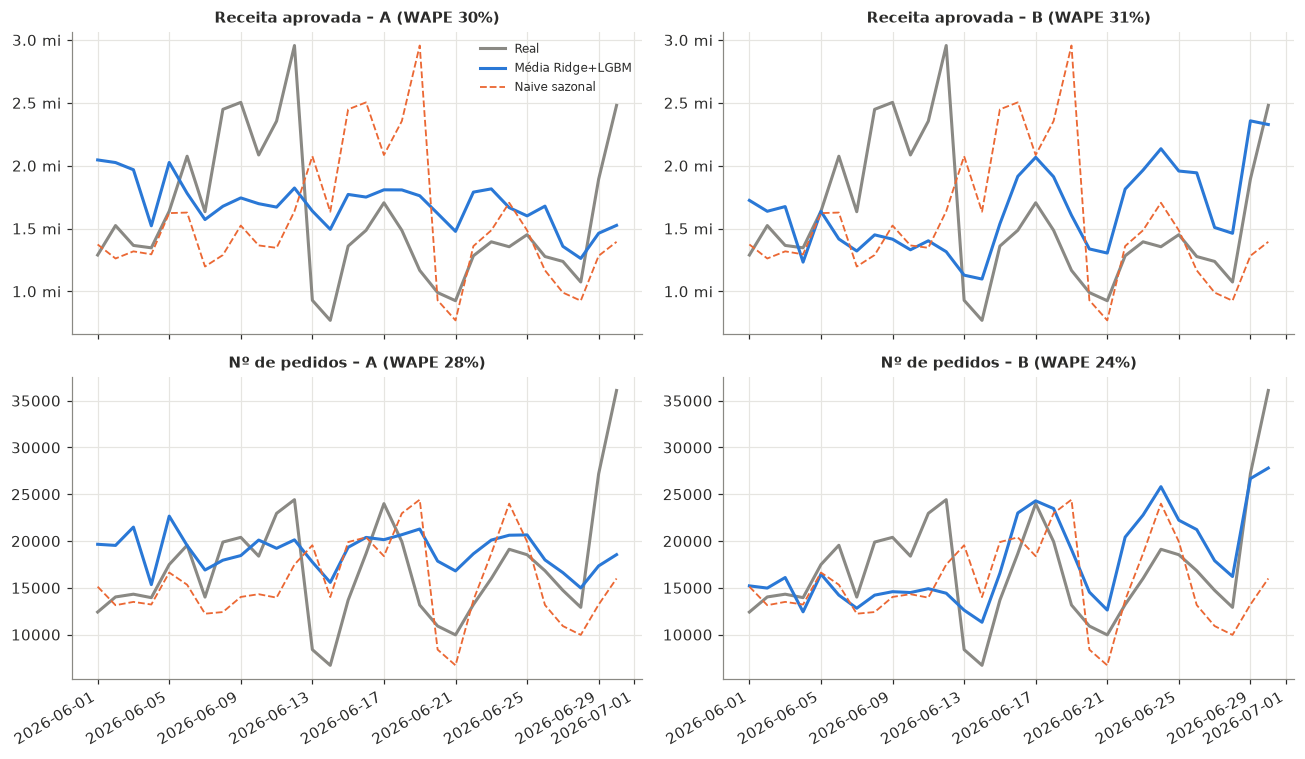

In [6]:
fig, axs = plt.subplots(2, 2, figsize=(12, 7), sharex=True)
for r, alvo in enumerate(ALVOS):
    for c, cen in enumerate(['A. Sem plano promocional', 'B. Com plano promocional (teto)']):
        ph, fit, Xc, yy, n = saidas[(alvo, cen)]
        ax = axs[r, c]; idx = yy.index[n:]
        ax.plot(idx, yy.iloc[n:], color=CINZA, label='Real')
        ax.plot(idx, ph[final[(alvo, cen)]], color=AZUL, label=final[(alvo, cen)])
        ax.plot(idx, ph['Naive sazonal'], color=LARANJA, lw=1.2, ls='--', label='Naive sazonal')
        w = tabelas[(alvo, cen)].loc[final[(alvo, cen)], 'WAPE holdout (%)']
        ax.set_title(f'{ALVOS[alvo]} – {cen[:1]} (WAPE {w:.0f}%)', fontsize=10)
        if alvo == 'receita_aprovada': ax.yaxis.set_major_formatter(FuncFormatter(milhoes))
        if r == 0 and c == 0: ax.legend(fontsize=8)
fig.autofmt_xdate(); plt.tight_layout(); salvar(fig, '08_holdout'); plt.show()

## Teste de sensibilidade: o cenário B é circular?
A taxa de desconto do dia é calculada com a **venda realizada do próprio dia** (desconto ÷ venda bruta), então
o cenário B usa uma informação que, na prática, só se conhece depois. Para medir o quanto isso favorece o B,
comparamos variantes da informação promocional, todas com o mesmo desenho de validação:
- **B1** taxa do dia (como no cenário B, é um limite superior otimista);
- **B2** taxa defasada em 7 dias e **B3** média de 7 dias defasada (não circulares, disponíveis na hora da previsão);
- **B4** taxa do dia com ruído multiplicativo (~20%), simulando um plano promocional impreciso.

In [7]:
def teste_sensibilidade():
    tx = d.tx_desc
    rng = np.random.default_rng(0)
    variantes = {
        'A. Sem informação de desconto': {},
        'B1. Taxa do dia (circular, otimista)': {'tx_dia': tx},
        'B2. Taxa defasada 7d': {'tx_l7': tx.shift(7)},
        'B3. Média 7d defasada': {'tx_m7': tx.shift(7).rolling(7).mean()},
        'B4. Taxa do dia com ruído de ~20%': {'tx_plano': tx * np.exp(rng.normal(0, 0.2, len(tx)))},
    }
    linhas = []
    for alvo in ALVOS:
        y = d[alvo]
        for vn, extra in variantes.items():
            X = calendario(y.index).join(com_defasagens(y))
            for k, v in extra.items(): X[k] = v
            X = X.dropna(); yy = y.loc[X.index]; n = len(yy) - DIAS_HOLDOUT
            def prever(a, b, c):
                return np.mean([prever_modelo(m, X.iloc[:a], yy.iloc[:a], X.iloc[b:c])[0] for m in modelos().values()], axis=0)
            wf = []
            for i in range(N_FOLDS):
                ini = n - PASSO * (N_FOLDS - i)
                wf.append(metricas(yy.iloc[ini:ini + PASSO], prever(ini, ini, ini + PASSO))['WAPE %'])
            ho = metricas(yy.iloc[n:], prever(n, n, len(yy)))['WAPE %']
            linhas.append({'alvo': alvo, 'informação promocional': vn, 'WAPE walk-forward (%)': np.mean(wf), 'WAPE holdout (%)': ho})
    return pd.DataFrame(linhas)

sens = teste_sensibilidade()
sens_tab = sens.pivot(index='informação promocional', columns='alvo', values=['WAPE walk-forward (%)', 'WAPE holdout (%)']).round(1)
sens_tab

WAPE walk-forward (%)                   \
alvo                                            nr_pedidos receita_aprovada   
informação promocional                                                        
A. Sem informação de desconto                         27.3             24.2   
B1. Taxa do dia (circular, otimista)                  24.8             24.7   
B2. Taxa defasada 7d                                  27.4             24.9   
B3. Média 7d defasada                                 28.3             24.8   
B4. Taxa do dia com ruído de ~20%                     26.7             24.7   

                                     WAPE holdout (%)                   
alvo                                       nr_pedidos receita_aprovada  
informação promocional                                                  
A. Sem informação de desconto                    27.5             30.1  
B1. Taxa do dia (circular, otimista)             24.2             28.4  
B2. Taxa defasada 7d                             28.6             29.2  
B3. Média 7d defasada                            26.0             26.9  
B4. Taxa do dia com ruído de ~20%                22.4             27.1

**Leitura honesta.** (média Ridge + LightGBM em todas as linhas)
- Com informação **não circular** (B2, B3) o erro **não melhora** frente ao cenário A: o histórico recente de desconto não prevê o dia seguinte.
- O ganho do B1 (principalmente em pedidos) vem de usar a taxa do próprio dia; é um **teto**, não uma expectativa realista.
- Com um plano com ruído (B4) o ganho se reduz e é pequeno em receita; só voltaria a ser relevante se o comercial fornecesse o plano com boa precisão.
- No holdout (apenas 30 dias) algumas variantes parecem ajudar a receita, mas o walk-forward, com mais janelas, não confirma; tratamos como ruído.
- **Conclusão:** o cenário A é o número a reportar como desempenho esperado; o B mostra o valor potencial de ter o calendário promocional bem estruturado.

In [8]:
R['sensibilidade'] = {f'{a}|{v}': {'wf': round(float(w), 1), 'ho': round(float(h), 1)}
                      for a, v, w, h in sens[['alvo', 'informação promocional', 'WAPE walk-forward (%)', 'WAPE holdout (%)']].itertuples(index=False)}

## Sensibilidade ao tratamento das linhas com receita ≤ 0
Comparamos o alvo "receita líquida" (como veio) com "soma de |receita|" (hipótese de inversão de sinal). Mesmo desenho e modelo
(média Ridge + LightGBM, cenário A).

In [9]:
_df = carregar()
y_abs = _df.groupby('data').receita_aprovada.apply(lambda s: s.abs().sum()).asfreq('D')
def wape_cenario_a(y):
    X = calendario(y.index).join(com_defasagens(y)).dropna(); yy = y.loc[X.index]; n = len(yy) - DIAS_HOLDOUT
    def prever(a, b, c):
        return np.mean([prever_modelo(m_, X.iloc[:a], yy.iloc[:a], X.iloc[b:c])[0] for m_ in modelos().values()], axis=0)
    wf = [metricas(yy.iloc[i:i + PASSO], prever(i, i, i + PASSO))['WAPE %'] for i in [n - PASSO * (N_FOLDS - k) for k in range(N_FOLDS)]]
    return np.mean(wf), metricas(yy.iloc[n:], prever(n, n, len(yy)))['WAPE %']
sens_alvo = pd.DataFrame({'Receita líquida (como veio)': wape_cenario_a(d.receita_aprovada), 'Soma de |receita|': wape_cenario_a(y_abs)},
                         index=['WAPE walk-forward (%)', 'WAPE holdout (%)']).round(1)
R['sens_tratamento_neg'] = sens_alvo.to_dict()
sens_alvo

,Receita líquida (como veio),Soma de |receita|
WAPE walk-forward (%),24.2,23.3
WAPE holdout (%),30.1,29.3


O erro relativo é praticamente o mesmo nas duas leituras: o tratamento muda o **nível** da receita (~9%), não a capacidade de previsão.

## Importância das variáveis
Duas leituras complementares sobre o LightGBM do cenário B (receita), no treino completo exceto holdout:
importância por permutação (queda de desempenho ao embaralhar a variável) e, no Ridge, os coeficientes padronizados.

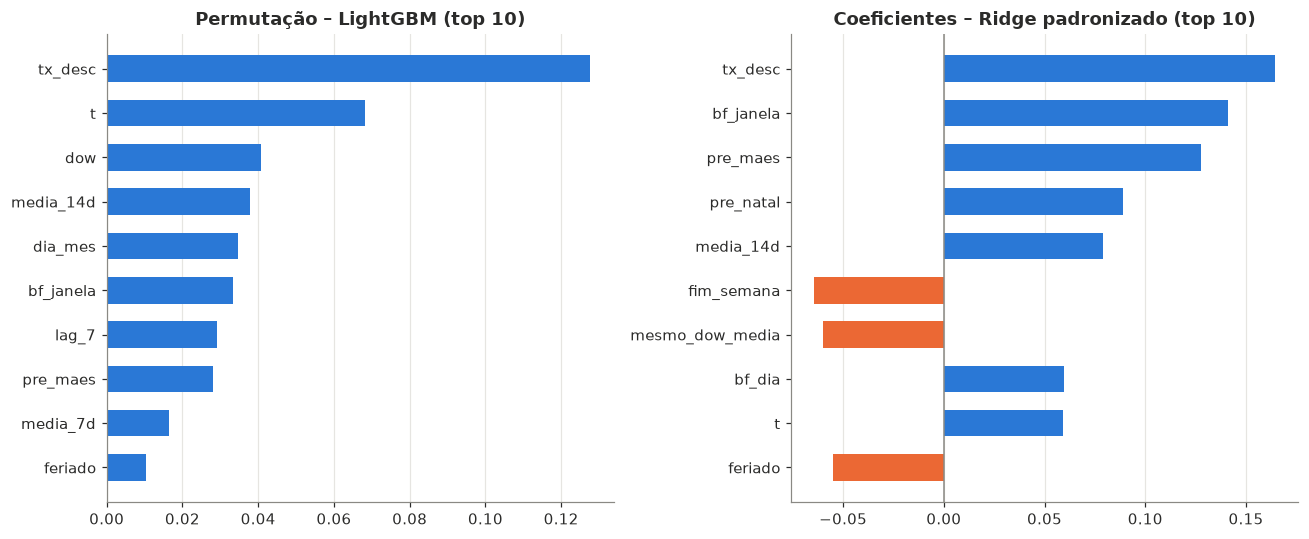

{'tx_desc': 0.1275, 't': 0.0681, 'dow': 0.0407, 'media_14d': 0.0378, 'dia_mes': 0.0346, 'bf_janela': 0.0332}
{'tx_desc': 0.164, 'bf_janela': 0.141, 'pre_maes': 0.127, 'pre_natal': 0.089, 'media_14d': 0.079, 'fim_semana': -0.064}


In [10]:
alvo, cen = 'receita_aprovada', 'B. Com plano promocional (teto)'
ph, fit, Xc, yy, n = saidas[(alvo, cen)]
Xtr, ytr = Xc.iloc[:n], np.log1p(yy.iloc[:n])
imp = permutation_importance(fit['LightGBM'], Xtr, ytr, n_repeats=30, random_state=0, scoring='neg_mean_absolute_error')
imp = pd.Series(imp.importances_mean, index=Xc.columns).sort_values()
coef = pd.Series(fit['Ridge'][-1].coef_, index=Xc.columns)
coef = coef.reindex(coef.abs().sort_values().index)
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
axs[0].barh(imp.index[-10:], imp.values[-10:], color=AZUL, height=.6); axs[0].set_title('Permutação – LightGBM (top 10)'); axs[0].grid(axis='y', visible=False)
cc = coef.iloc[-10:]
axs[1].barh(cc.index, cc.values, color=[AZUL if v >= 0 else LARANJA for v in cc.values], height=.6); axs[1].axvline(0, color=CINZA, lw=1)
axs[1].set_title('Coeficientes – Ridge padronizado (top 10)'); axs[1].grid(axis='y', visible=False)
plt.tight_layout(); salvar(fig, '09_importancia'); plt.show()
R['top_perm'] = imp.sort_values(ascending=False).head(6).round(4).to_dict()
R['top_coef'] = coef.reindex(coef.abs().sort_values(ascending=False).index).head(6).round(3).to_dict()
print(R['top_perm']); print(R['top_coef'])

**Cuidado na leitura.** `tx_desc` lidera nos dois métodos, seguido de tendência (`t`), dia da semana e histórico recente. Os coeficientes de `bf_janela`, `pre_natal` e `pre_maes` aparecem altos no Ridge, mas cada um vem de **um único evento** na base: indicam que o modelo acomodou aqueles picos, não que o efeito esteja medido com precisão.

## Análise de resíduos e limites do modelo

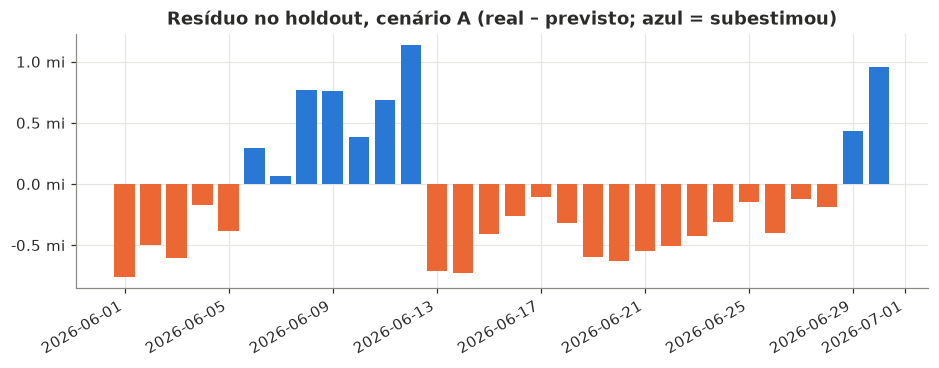

Maiores erros absolutos:


data
2026-06-12    1133867.0
2026-06-30     954464.0
2026-06-08     771399.0
2026-06-09     760108.0
2026-06-01     756547.0
Name: receita_aprovada, dtype: float64

In [11]:
ph, fit, Xc, yy, n = saidas[('receita_aprovada', 'A. Sem plano promocional')]
res = (yy.iloc[n:] - ph[final[('receita_aprovada', 'A. Sem plano promocional')]])
fig, ax = plt.subplots(figsize=(10, 3.4))
ax.bar(res.index, res.values, color=[AZUL if v >= 0 else LARANJA for v in res.values], width=.8)
ax.yaxis.set_major_formatter(FuncFormatter(milhoes)); ax.set_title('Resíduo no holdout, cenário A (real – previsto; azul = subestimou)')
fig.autofmt_xdate(); salvar(fig, '10_residuos'); plt.show()
print('Maiores erros absolutos:'); display(res.abs().sort_values(ascending=False).head(5).round(0))

**Limites que valem explicitar:**
1. **Um único Natal, uma única Black Friday, nenhum ciclo anual:** efeitos sazonais anuais são estimados com 1 observação; não validamos o comportamento deles fora da amostra.
2. **Picos promocionais e eventos não calendarizados** geram os maiores resíduos (12/06, 30/06, 8–9/06 e 01/06 no holdout); a queda de 13–14/06 também fica sem explicação. Sem um calendário de mídia/campanhas e de eventos externos, esse erro é difícil de reduzir.
3. **O cenário B é um teto otimista:** usa a taxa de desconto do próprio dia, calculada com a venda realizada. O teste de sensibilidade mostra que, sem essa circularidade, não há ganho sobre o cenário A.
4. WAPE na faixa de 20–30% é adequado para planejamento semanal agregado, não para metas diárias rígidas.

In [12]:
for k, v in final.items(): print(k, '->', v)
R['resumo'] = {f'{a}|{c}': {'modelo': final[(a, c)], **{kk: round(float(vv), 1) for kk, vv in resumo.loc[[(a, c)]].iloc[0].items() if kk != 'modelo escolhido'}} for (a, c) in final}
R['tabelas'] = {f'{a}|{c}': t.round(1).to_dict('index') for (a, c), t in tabelas.items()}
json.dump(R, open('../reports/resultados_modelo.json', 'w'), ensure_ascii=False, indent=2, default=float)

('receita_aprovada', 'A. Sem plano promocional') -> Média Ridge+LGBM
('receita_aprovada', 'B. Com plano promocional (teto)') -> Ridge
('nr_pedidos', 'A. Sem plano promocional') -> Média Ridge+LGBM
('nr_pedidos', 'B. Com plano promocional (teto)') -> Média Ridge+LGBM
